<a href="https://colab.research.google.com/github/210124cse-jpg/ML-LAB/blob/main/210124_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset from GitHub
dataset_url = 'https://raw.githubusercontent.com/210124cse-jpg/ML-LAB/refs/heads/main/train.csv'
dataset = pd.read_csv(dataset_url)

dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Handle missing values
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].mode()[0])
dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
dataset['Sex'] = label_encoder.fit_transform(dataset['Sex'])
dataset['Embarked'] = label_encoder.fit_transform(dataset['Embarked'])

dataset = dataset.drop(columns=['Name', 'Ticket', 'Cabin'])

dataset.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,1,22.0,1,0,7.2500,2
1,2,1,1,0,38.0,1,0,71.2833,0
2,3,1,3,0,26.0,0,0,7.9250,2
3,4,1,1,0,35.0,1,0,53.1000,2
4,5,0,3,1,35.0,0,0,8.0500,2


In [5]:
# Split the dataset into features (X) and target (y)
X = dataset.drop(columns=['Survived'])
y = dataset['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(X_train.shape, X_test.shape)


((712, 8), (179, 8))

In [6]:
# Implementing Decision Tree (CART) using Gini criterion
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)

cart_param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

cart_grid_search = GridSearchCV(cart_model, cart_param_grid, cv=5, scoring='accuracy')
cart_grid_search.fit(X_train, y_train)

cart_grid_search.best_params_, cart_grid_search.best_score_


({'max_depth': 3, 'min_samples_split': 2}, np.float64(0.8159854230276766))

In [7]:
# Implementing Decision Tree (ID3) using Entropy criterion
id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

id3_grid_search = GridSearchCV(id3_model, cart_param_grid, cv=5, scoring='accuracy')
id3_grid_search.fit(X_train, y_train)

id3_grid_search.best_params_, id3_grid_search.best_score_


({'max_depth': 3, 'min_samples_split': 2}, np.float64(0.8187826258248794))

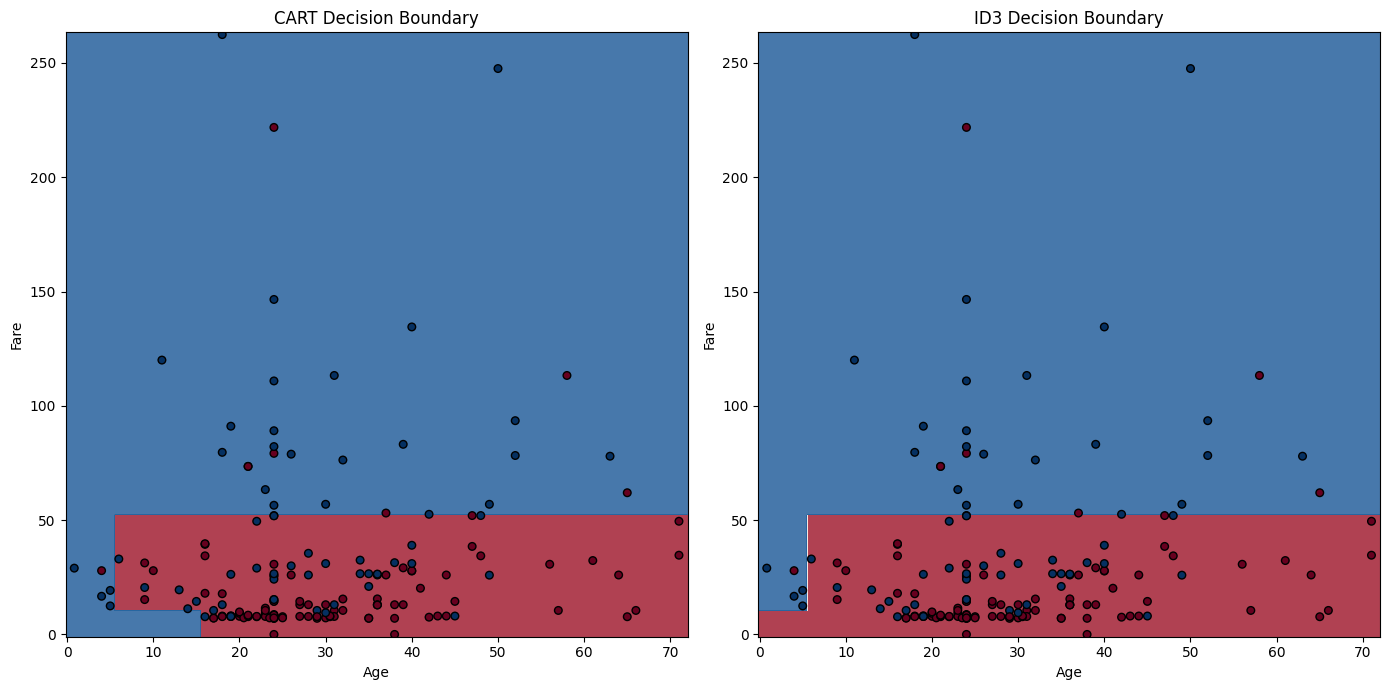

In [13]:
# Select two features (e.g., 'Age' and 'Fare') for the decision boundary plot
X_2d = X[['Age', 'Fare']]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

def plot_decision_boundary(model, X, y, ax, title="Decision Boundary"):
    h = .02
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.RdBu, s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    return scatter

cart_model_2d = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2)
cart_model_2d.fit(X_train_2d, y_train_2d)

id3_model_2d = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=2)
id3_model_2d.fit(X_train_2d, y_train_2d)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))

plot_decision_boundary(cart_model_2d, X_test_2d, y_test_2d, axs[0], title="CART Decision Boundary")
plot_decision_boundary(id3_model_2d, X_test_2d, y_test_2d, axs[1], title="ID3 Decision Boundary")

plt.tight_layout()
plt.show()

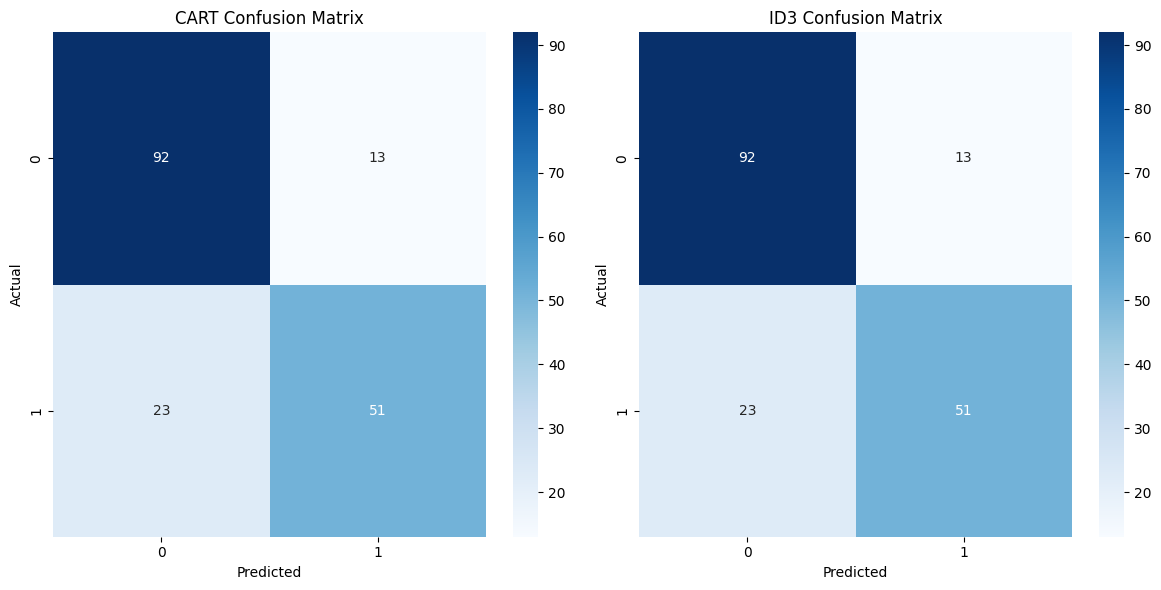

In [8]:
# Predict on the test set using both models
cart_predictions = cart_grid_search.best_estimator_.predict(X_test)
id3_predictions = id3_grid_search.best_estimator_.predict(X_test)

cart_conf_matrix = confusion_matrix(y_test, cart_predictions)
id3_conf_matrix = confusion_matrix(y_test, id3_predictions)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cart_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('CART Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(id3_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('ID3 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


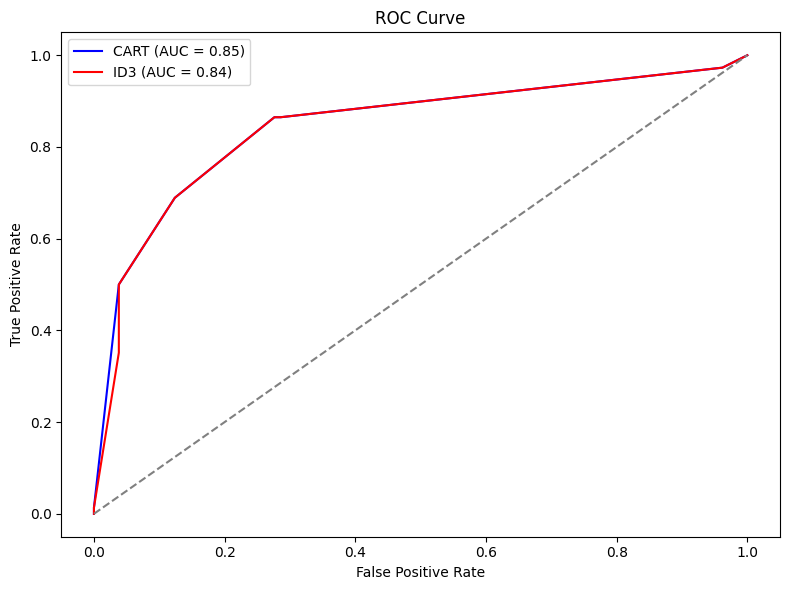

In [9]:
# Compute ROC curve and AUC for both models
cart_fpr, cart_tpr, _ = roc_curve(y_test, cart_grid_search.best_estimator_.predict_proba(X_test)[:, 1])
id3_fpr, id3_tpr, _ = roc_curve(y_test, id3_grid_search.best_estimator_.predict_proba(X_test)[:, 1])

cart_auc = auc(cart_fpr, cart_tpr)
id3_auc = auc(id3_fpr, id3_tpr)

plt.figure(figsize=(8, 6))
plt.plot(cart_fpr, cart_tpr, color='blue', label=f'CART (AUC = {cart_auc:.2f})')
plt.plot(id3_fpr, id3_tpr, color='red', label=f'ID3 (AUC = {id3_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()


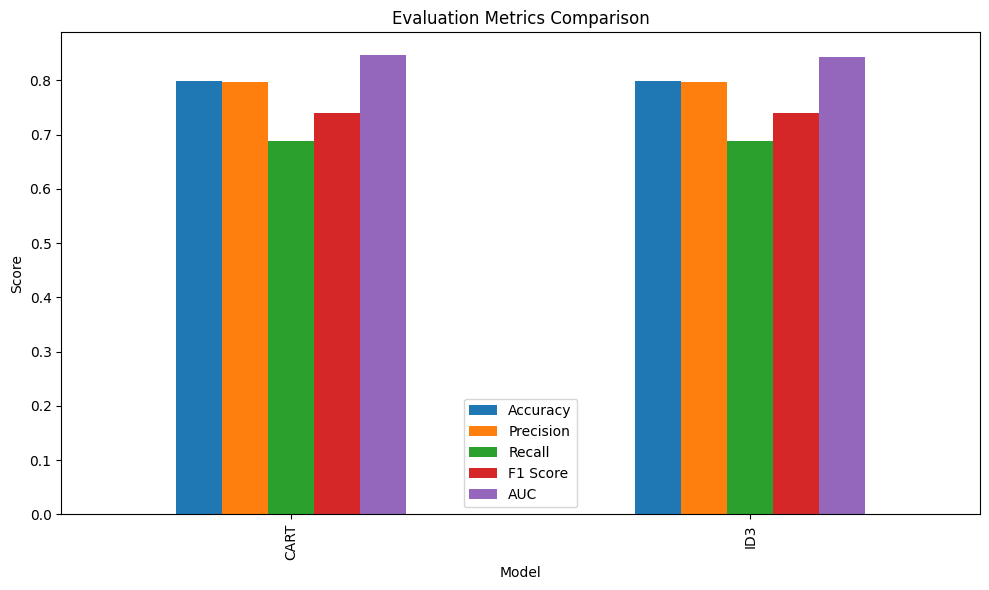

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate evaluation metrics for both models
cart_accuracy = accuracy_score(y_test, cart_predictions)
id3_accuracy = accuracy_score(y_test, id3_predictions)

cart_precision = precision_score(y_test, cart_predictions)
id3_precision = precision_score(y_test, id3_predictions)

cart_recall = recall_score(y_test, cart_predictions)
id3_recall = recall_score(y_test, id3_predictions)

cart_f1 = f1_score(y_test, cart_predictions)
id3_f1 = f1_score(y_test, id3_predictions)

cart_auc = auc(cart_fpr, cart_tpr)
id3_auc = auc(id3_fpr, id3_tpr)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
cart_metrics = [
    cart_accuracy,
    cart_precision,
    cart_recall,
    cart_f1,
    cart_auc
]

id3_metrics = [
    id3_accuracy,
    id3_precision,
    id3_recall,
    id3_f1,
    id3_auc
]

metrics_df = pd.DataFrame([cart_metrics, id3_metrics], columns=metrics, index=['CART', 'ID3'])

metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Evaluation Metrics Comparison')
plt.ylabel('Score')
plt.xlabel('Model')

plt.tight_layout()
plt.show()


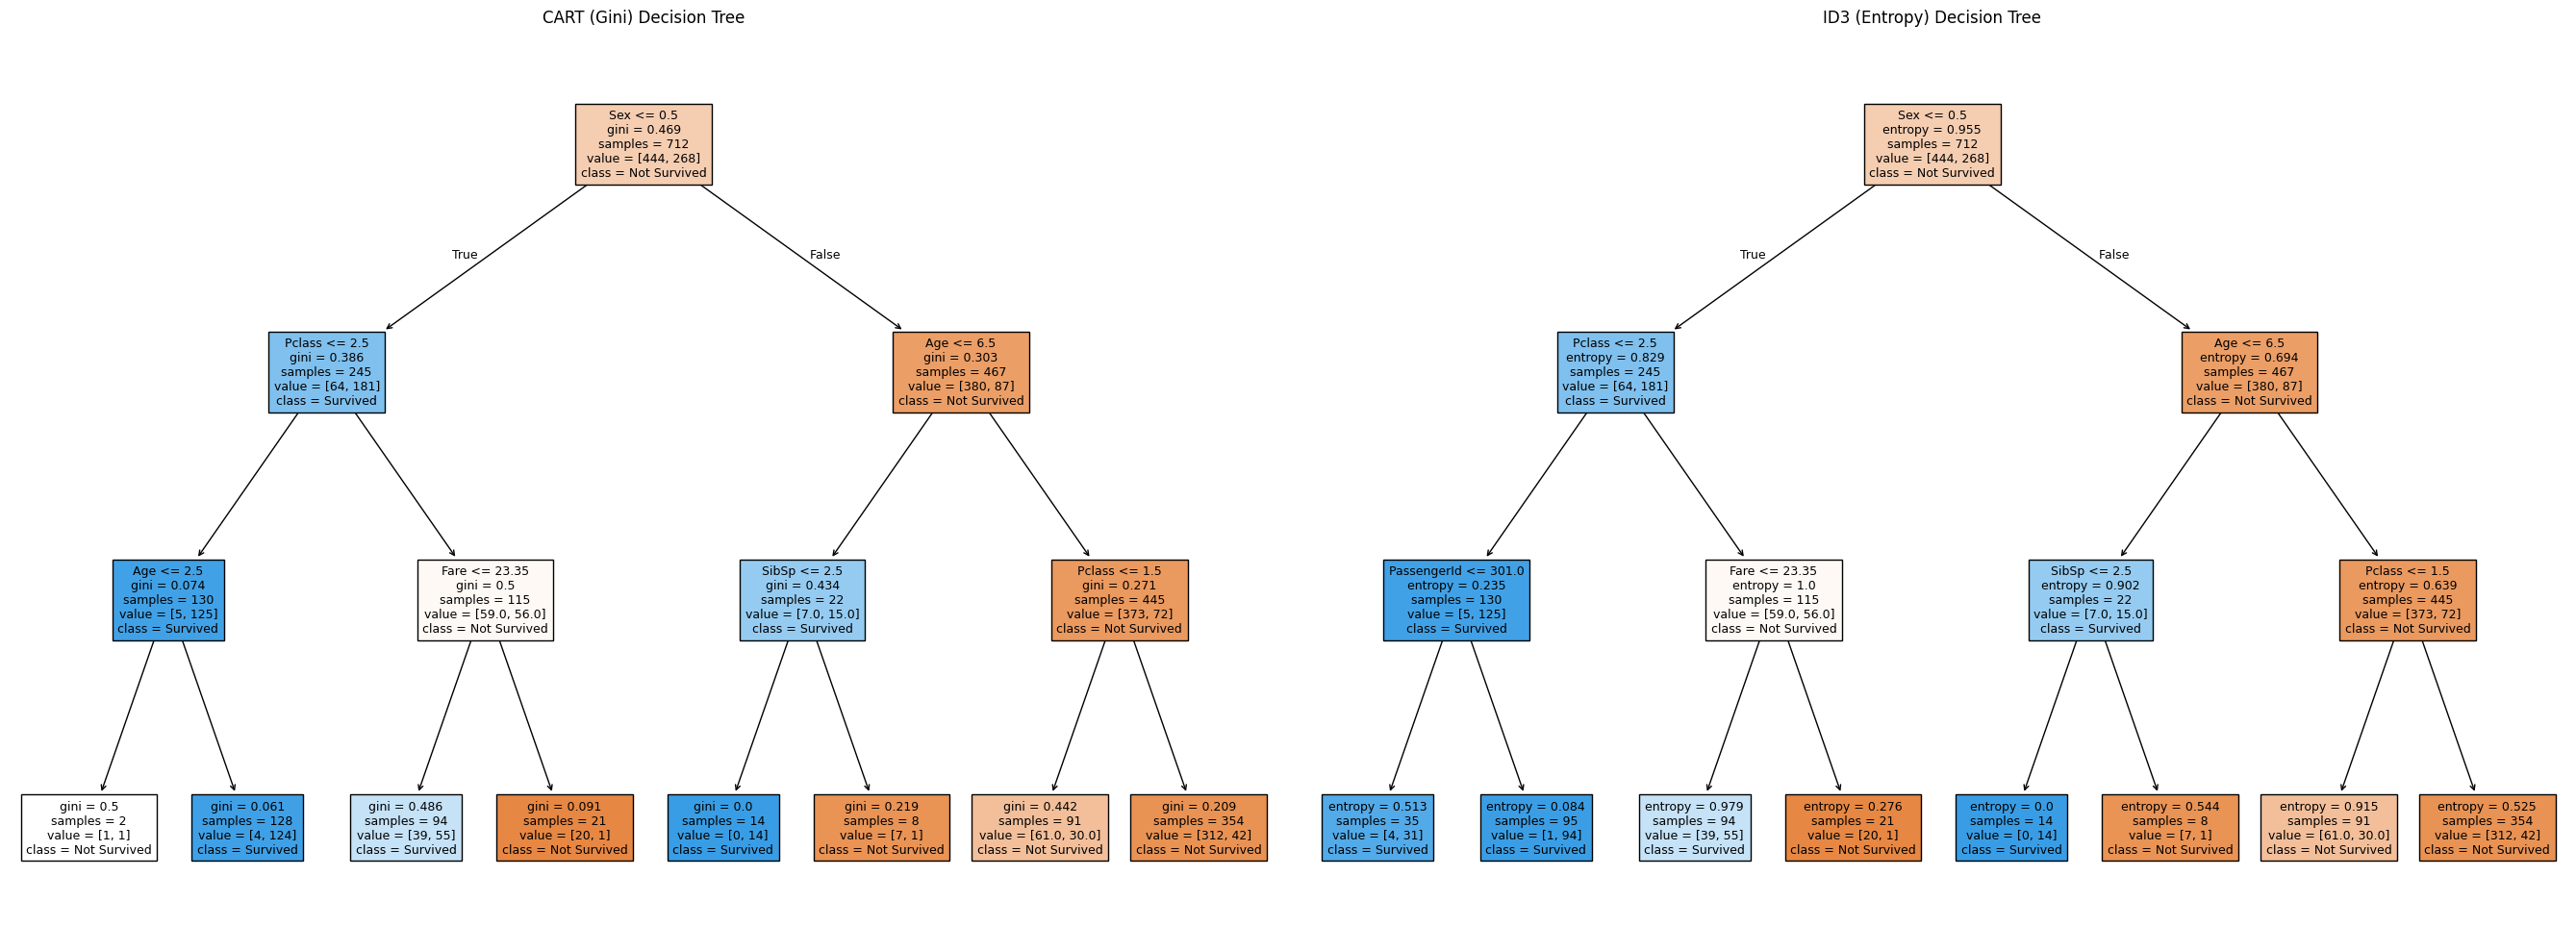

In [11]:
# Plot the Decision Tree structure for both models
fig, axs = plt.subplots(1, 2, figsize=(27,10))

plot_tree(cart_grid_search.best_estimator_, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'], ax=axs[0],fontsize=9)
axs[0].set_title('CART (Gini) Decision Tree')

plot_tree(id3_grid_search.best_estimator_, filled=True, feature_names=X.columns, class_names=['Not Survived', 'Survived'], ax=axs[1],fontsize=9)
axs[1].set_title('ID3 (Entropy) Decision Tree')

plt.tight_layout()
plt.show()
